In [1]:
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

LABEL_NAMES  = {"1": "ET", "2": "TC", "3": "WT"}
SKIP_METRICS = {"n_pred", "n_ref"}


def analyze_nnunet_results(base_path, save_dir=None):
    """
    Parses nnUNet summary.json files from subfolders containing '_100epochs_'.

    Unit of observation: per-fold mean (one value per fold per model per label
    per metric). This gives 5 observations per model for 5-fold CV, which is
    the correct input for cross-validation comparison and boxplots.

    Parameters
    ----------
    base_path : str
        Path to nnUNet_results/Dataset001_FeTS/
    save_dir : str or None
        If given, figures are saved there as PNGs instead of shown interactively.
    """

    # ── 1. Collect per-fold means ─────────────────────────────────────────────
    # One row per (model, fold, label, metric) — value is the mean over cases
    # in that fold. This is the correct aggregation level for CV comparison.
    fold_records = []

    all_summary_files = sorted(glob.glob(
        os.path.join(base_path, "*_100epochs_*", "fold_*", "validation", "summary.json")
    ))

    if not all_summary_files:
        print("No matching summary files found.")
        return None, None

    for summary_file in all_summary_files:
        parts      = summary_file.replace("\\", "/").split("/")
        folder     = parts[-4]          # e.g. nnUNetTrainerX__nnUNetPlans__3d_fullres_100epochs_...
        fold_id    = parts[-3]          # e.g. fold_0
        model_name = folder.split("_100epochs_")[0].split("Trainer")[0]
        if model_name != "nnUNet":
            model_name = model_name.split("nnUNet_")[1]

        with open(summary_file) as f:
            try:
                summary_data = json.load(f)
            except json.JSONDecodeError:
                print(f"Warning: could not decode {summary_file}")
                continue

        if "metric_per_case" not in summary_data:
            continue

        # Accumulate per-label, per-metric values across cases in this fold
        # structure: {label: {metric: [val_case0, val_case1, ...]}}
        fold_values = {}

        for case in summary_data["metric_per_case"]:
            metrics_dict = case.get("metrics", {})
            for label in ["1", "2", "3"]:
                if label not in metrics_dict:
                    continue
                if label not in fold_values:
                    fold_values[label] = {}
                for metric_name, val in metrics_dict[label].items():
                    if metric_name in SKIP_METRICS:
                        continue
                    if val is None or (isinstance(val, float) and np.isnan(val)):
                        continue
                    fold_values[label].setdefault(metric_name, []).append(float(val))

        # Compute per-fold mean across cases and store as one observation
        for label, metric_dict in fold_values.items():
            for metric_name, values in metric_dict.items():
                fold_records.append({
                    "Model":   model_name,
                    "Fold":    fold_id,
                    "Label":   label,
                    "Metric":  metric_name,
                    "Value":   float(np.mean(values)),   # ← fold mean, the unit of observation
                })

        # ── Mean Dice across labels (per fold, per case → then fold mean) ────
        # For each case average Dice across labels present, then average over
        # cases in the fold. This gives one "Mean Dice" observation per fold.
        case_mean_dices = []
        for case in summary_data["metric_per_case"]:
            metrics_dict = case.get("metrics", {})
            label_dices = [
                metrics_dict[lbl]["Dice"]
                for lbl in ["1", "2", "3"]
                if lbl in metrics_dict
                and "Dice" in metrics_dict[lbl]
                and metrics_dict[lbl]["Dice"] is not None
                and not np.isnan(float(metrics_dict[lbl]["Dice"]))
            ]
            if label_dices:
                case_mean_dices.append(float(np.mean(label_dices)))

        if case_mean_dices:
            fold_records.append({
                "Model":  model_name,
                "Fold":   fold_id,
                "Label":  "mean",
                "Metric": "Dice",
                "Value":  float(np.mean(case_mean_dices)),
            })

    if not fold_records:
        print("No data collected.")
        return None, None

    df = pd.DataFrame(fold_records)
    # df now has shape (n_models × n_folds × n_labels × n_metrics) rows
    # each Value is a fold-level mean — correct unit for CV boxplots

    # ── 2. Stats table ────────────────────────────────────────────────────────
    # Mean and std over the 5 fold-means = the standard CV summary statistic
    stats = (
        df.groupby(["Model", "Metric", "Label"])["Value"]
        .agg(["mean", "std", "median"])
        .reset_index()
    )

    all_label_names = {**LABEL_NAMES, "mean": "Mean Dice"}

    print("=== Mean ± Std over folds (median) ===")
    for metric in sorted(stats["Metric"].unique()):
        print(f"\n  {metric}")
        sub = stats[stats["Metric"] == metric].sort_values(["Label", "Model"])
        for _, row in sub.iterrows():
            lname = all_label_names.get(row["Label"], row["Label"])
            print(
                f"    [{lname:^10}]  {row['Model']:45s}"
                f"  {row['mean']:.4f} ± {row['std']:.4f}"
                f"  (median {row['median']:.4f})"
            )

    # ── 3. Plotting — one figure per (metric, label) ──────────────────────────
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    sns.set_theme(style="whitegrid", font_scale=1.05)
    palette = sns.color_palette("Set2")

    unique_metrics = sorted(df["Metric"].unique())

    labels_to_plot = [
        ("1",    LABEL_NAMES["1"]),
        ("2",    LABEL_NAMES["2"]),
        ("3",    LABEL_NAMES["3"]),
        ("mean", "Mean Dice"),
    ]

    for metric in unique_metrics:
        metric_df = df[df["Metric"] == metric]

        for label_key, label_display in labels_to_plot:
            label_df = metric_df[metric_df["Label"] == label_key]
            if label_df.empty:
                continue

            n_models = label_df["Model"].nunique()
            fig, ax  = plt.subplots(figsize=(max(6, n_models * 1.6), 5))

            sns.boxplot(
                data=label_df,
                x="Model",
                y="Value",
                palette=palette,
                width=0.55,
                linewidth=1.2,
                # With only 5 folds each point matters — show them all
                flierprops=dict(marker="o", markersize=5, alpha=0.7),
                ax=ax,
            )

            # Overlay individual fold points so the 5 observations are visible
            sns.stripplot(
                data=label_df,
                x="Model",
                y="Value",
                color="black",
                size=5,
                alpha=0.6,
                jitter=False,
                ax=ax,
            )

            ax.set_title(
                f"{metric}  —  {label_display}  (n=5 folds per model)",
                fontsize=12, fontweight="bold",
            )
            ax.set_ylabel(f"Fold mean {metric}")
            ax.set_xlabel("")
            ax.tick_params(axis="x", rotation=35)

            ax.set_xticklabels(
                [t.get_text().replace("nnUNetTrainer", "")
                 for t in ax.get_xticklabels()],
                ha="right",
            )

            fig.tight_layout()

            if save_dir:
                slug  = label_display.replace(" ", "_")
                fname = os.path.join(save_dir, f"{metric}_{slug}.png")
                fig.savefig(fname, dpi=150, bbox_inches="tight")
                print(f"Saved: {fname}")
                plt.close(fig)
            else:
                plt.show()

    return stats, df

=== Mean ± Std over folds (median) ===

  Dice
    [    ET    ]  32AttnLongTokenUNet                            0.7694 ± 0.0178  (median 0.7675)
    [    ET    ]  32AttnTokenUNet                                0.7685 ± 0.0155  (median 0.7666)
    [    ET    ]  32MLPTokenUNet                                 0.7723 ± 0.0150  (median 0.7704)
    [    ET    ]  32TokenUNet                                    0.7722 ± 0.0212  (median 0.7694)
    [    ET    ]  8AttnTokenUNet                                 0.7710 ± 0.0154  (median 0.7690)
    [    ET    ]  8MLPTokenUNet                                  0.7693 ± 0.0149  (median 0.7654)
    [    ET    ]  8TokenUNet                                     0.7713 ± 0.0172  (median 0.7672)
    [    ET    ]  NDSnnUNet                                      0.7801 ± 0.0165  (median 0.7760)
    [    ET    ]  NoTokenUNet                                    0.7719 ± 0.0181  (median 0.7692)
    [    ET    ]  SwinUNETR                                      0.7660

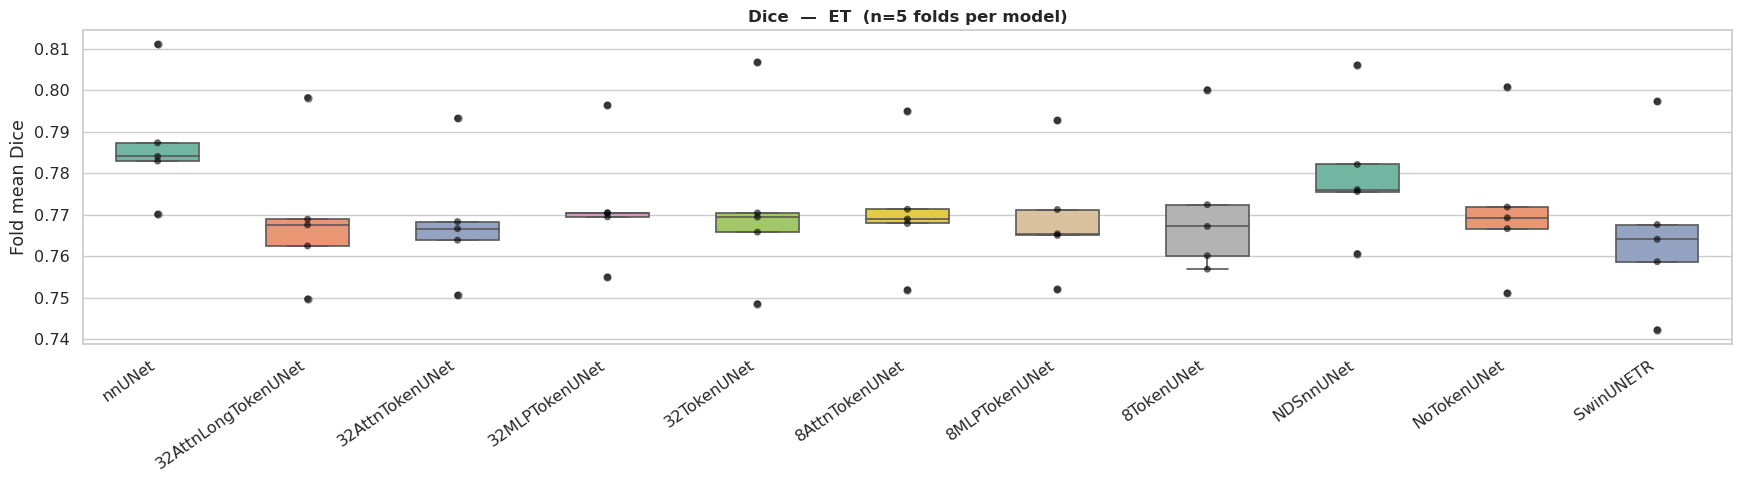

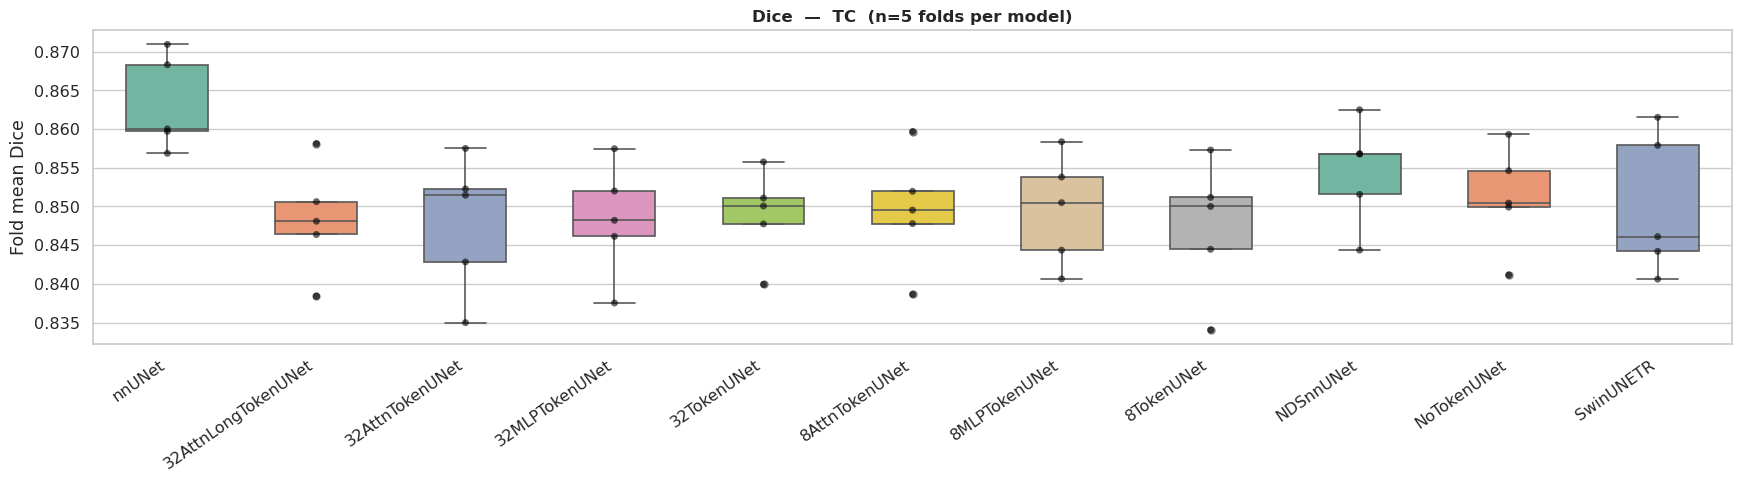

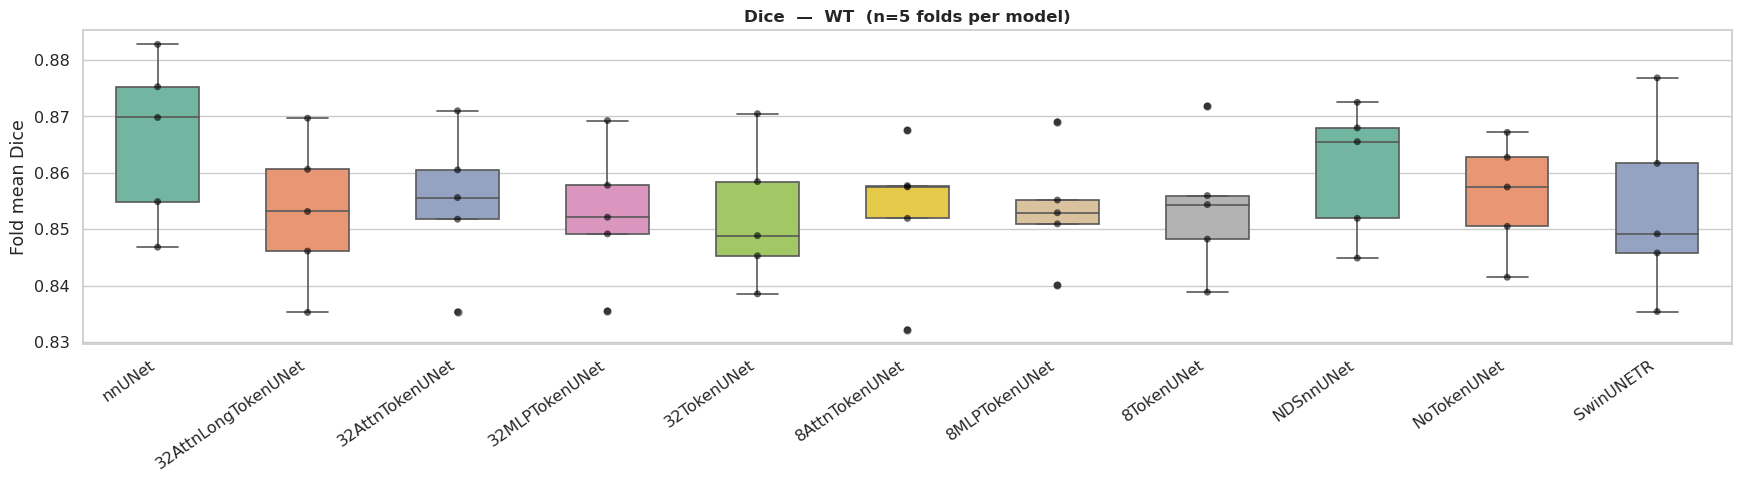

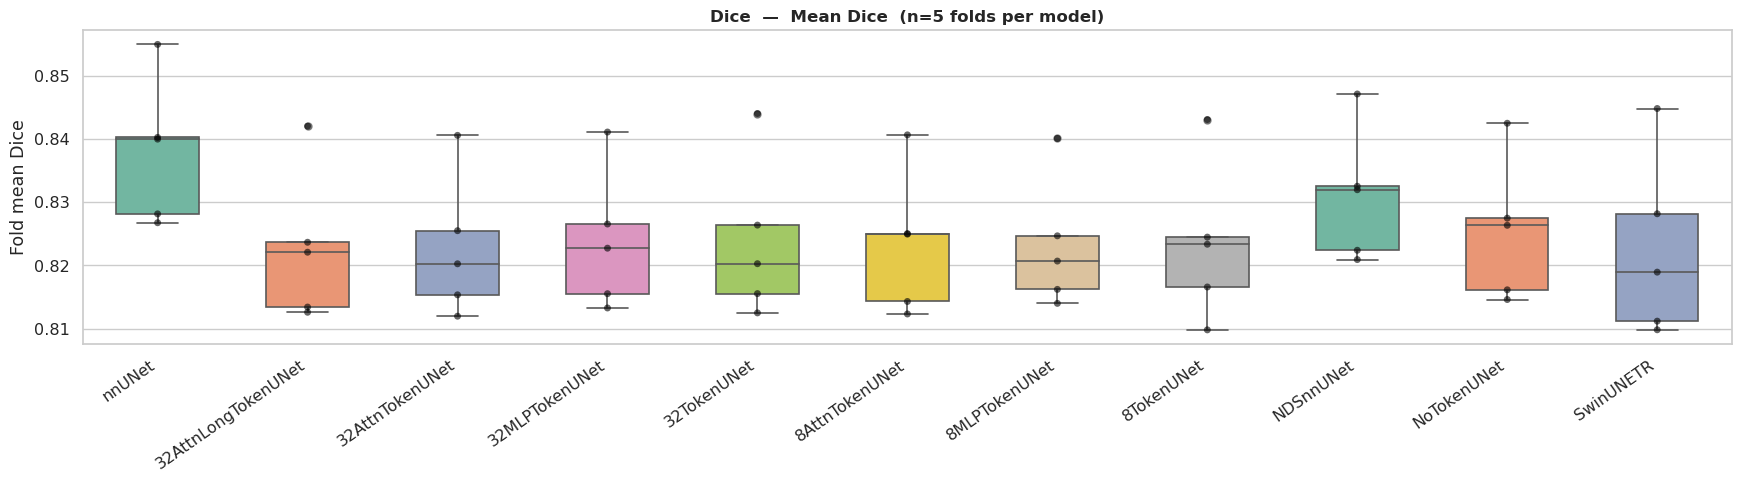

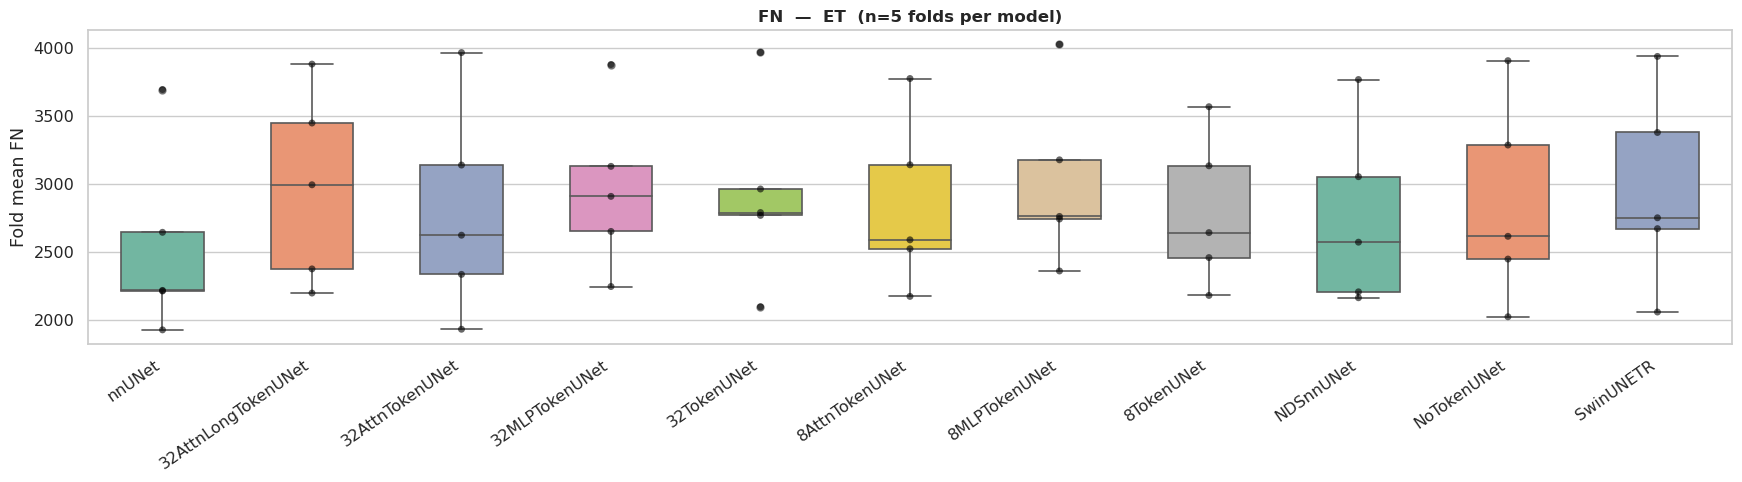

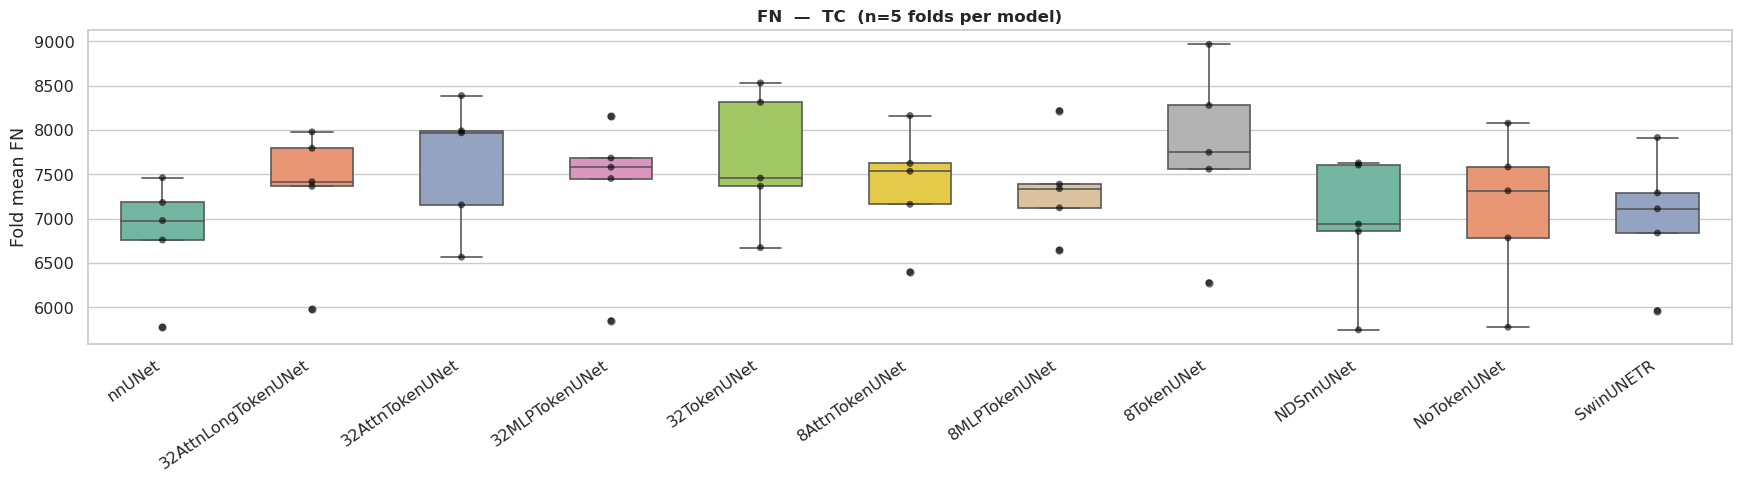

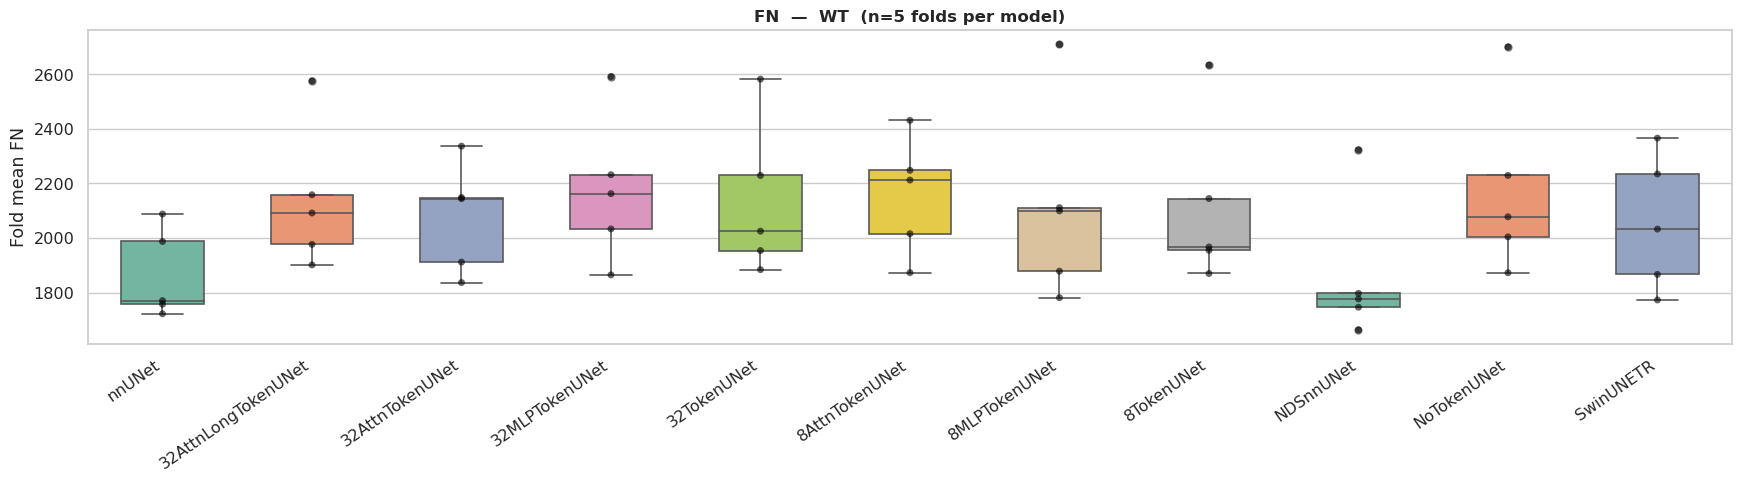

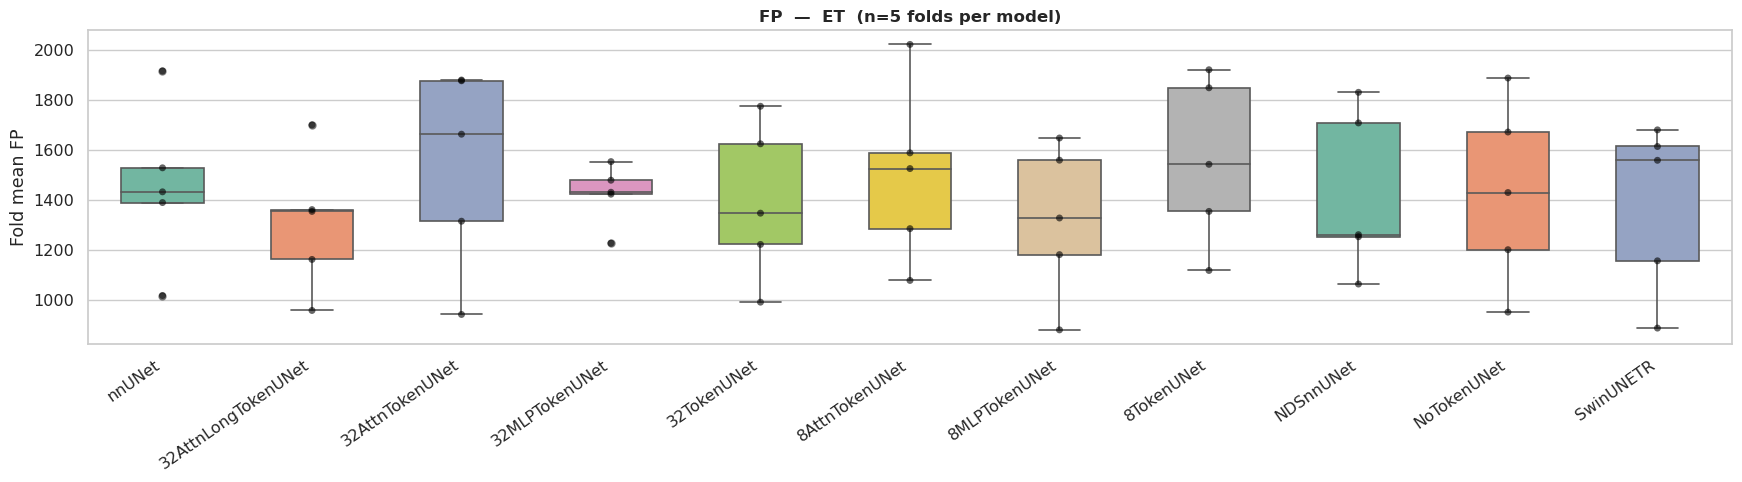

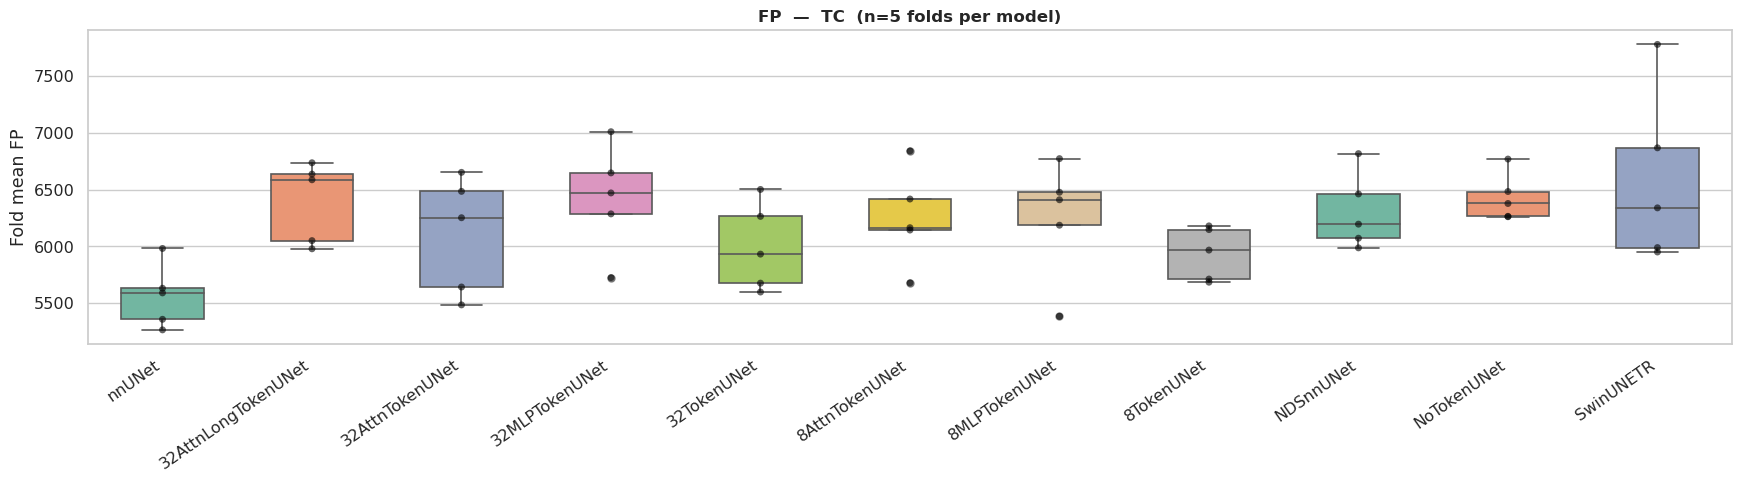

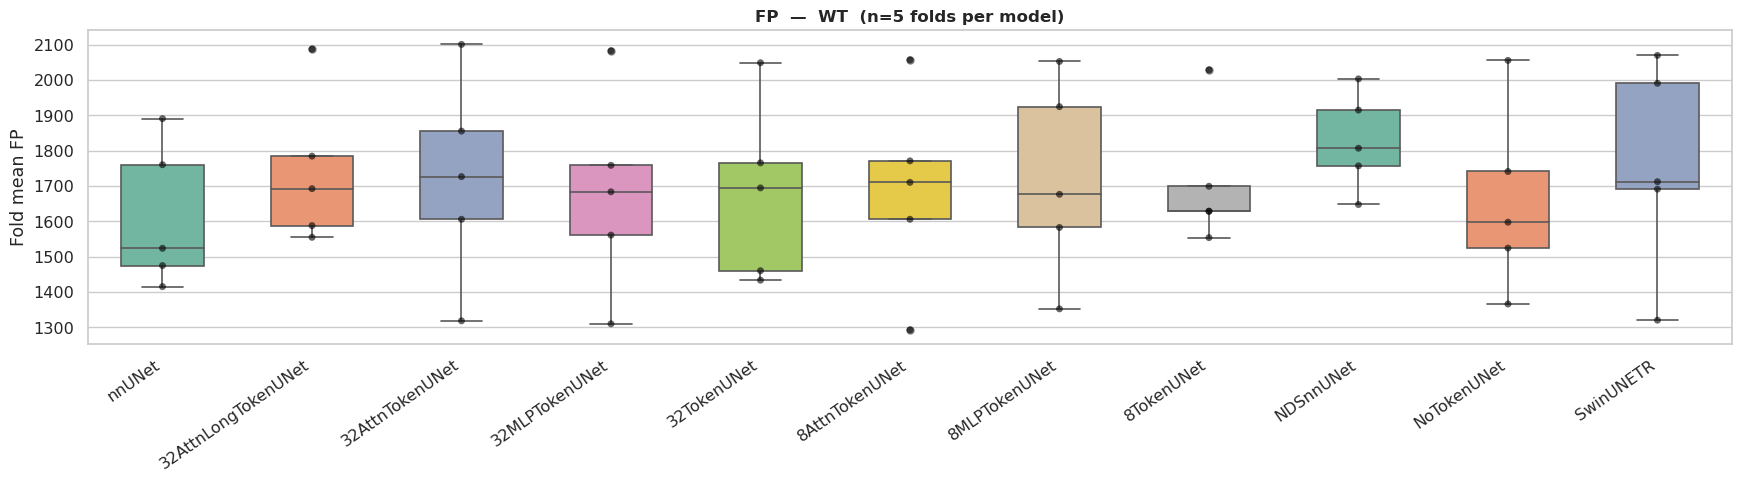

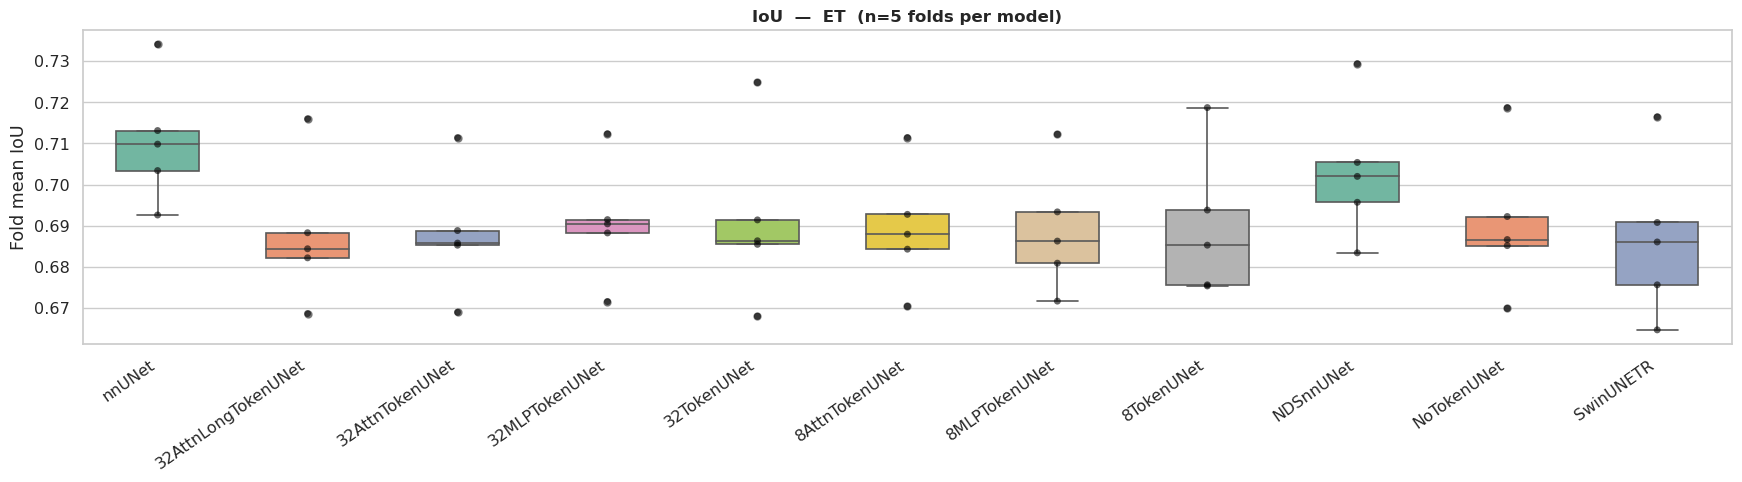

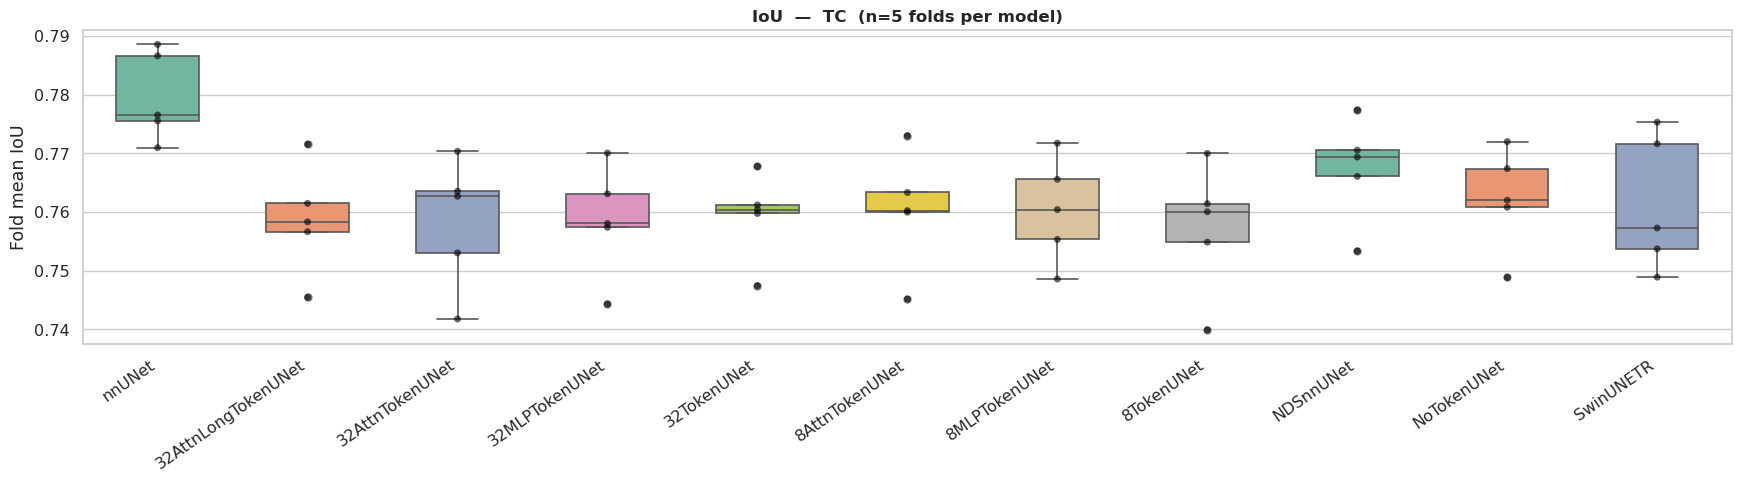

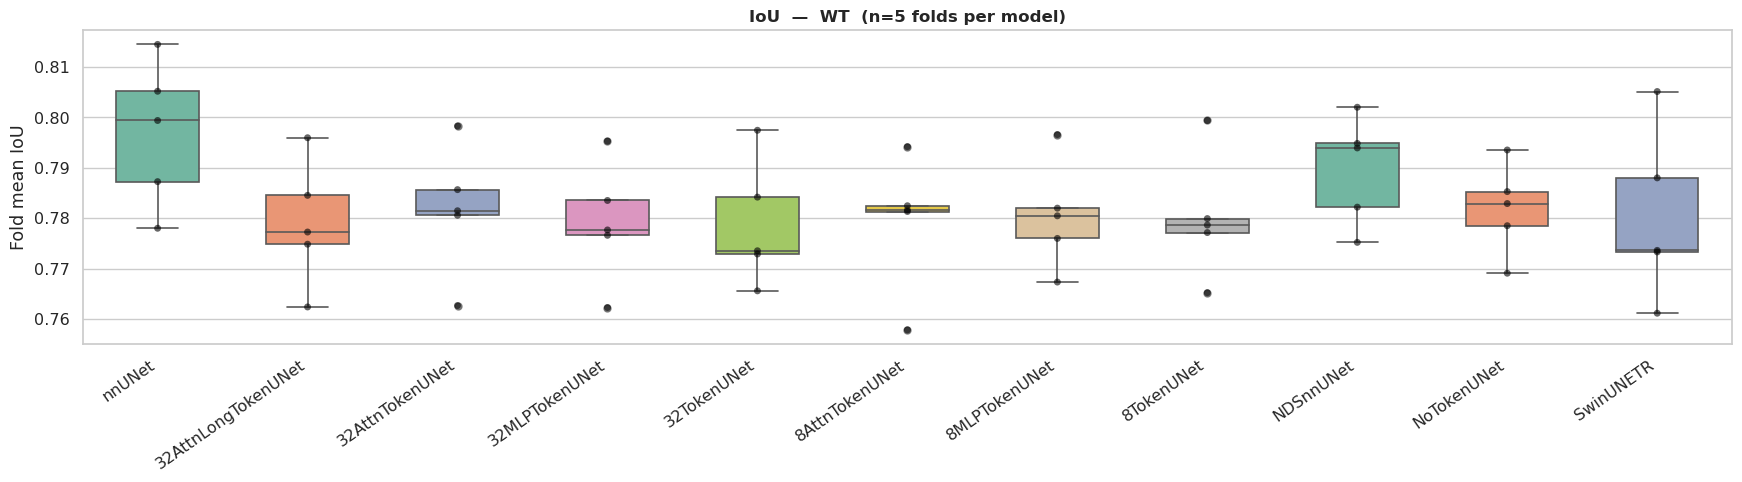

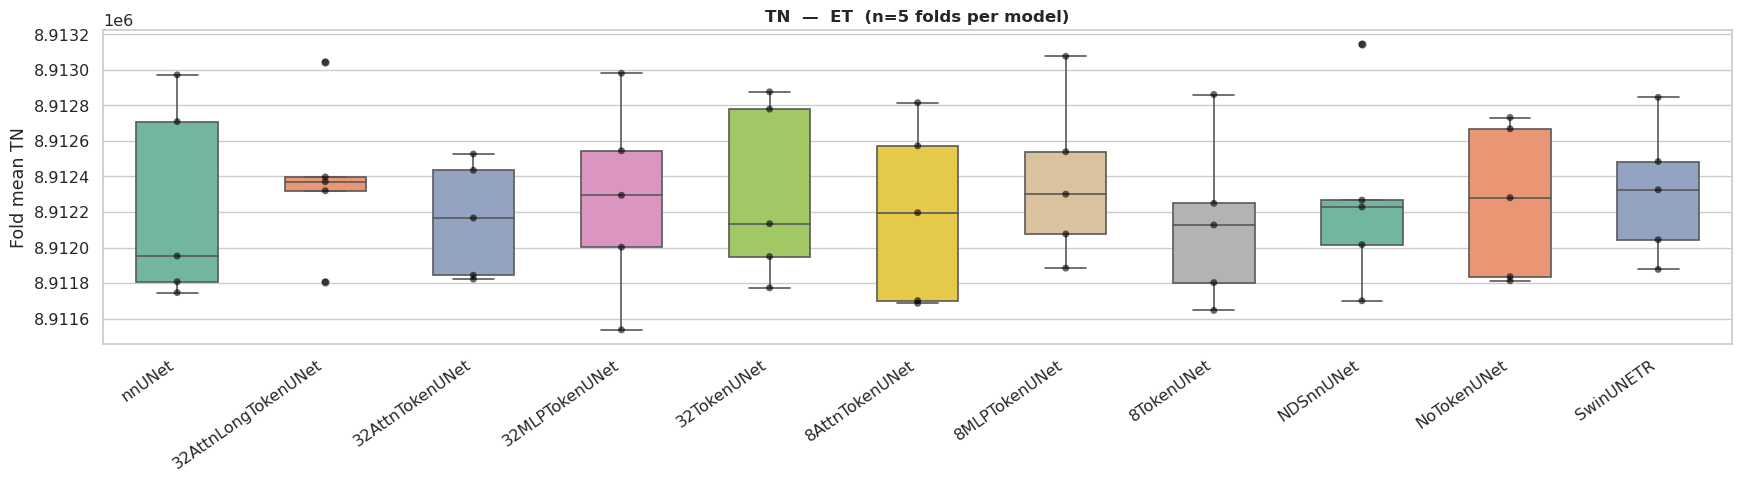

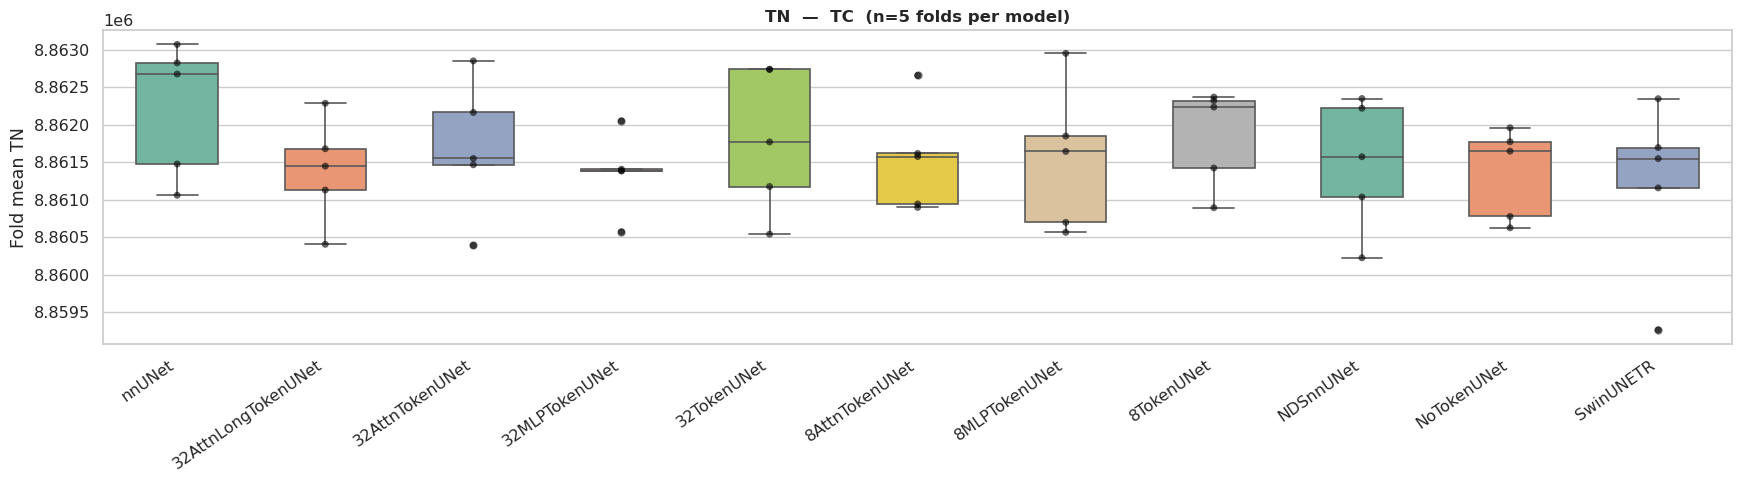

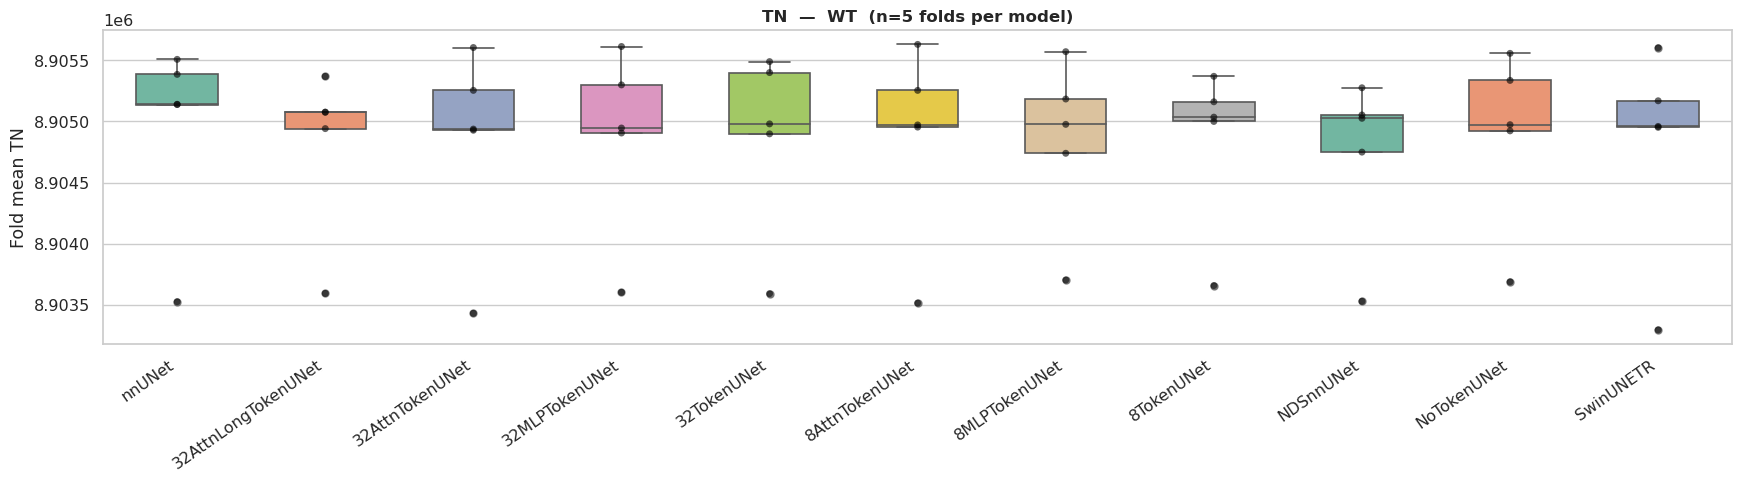

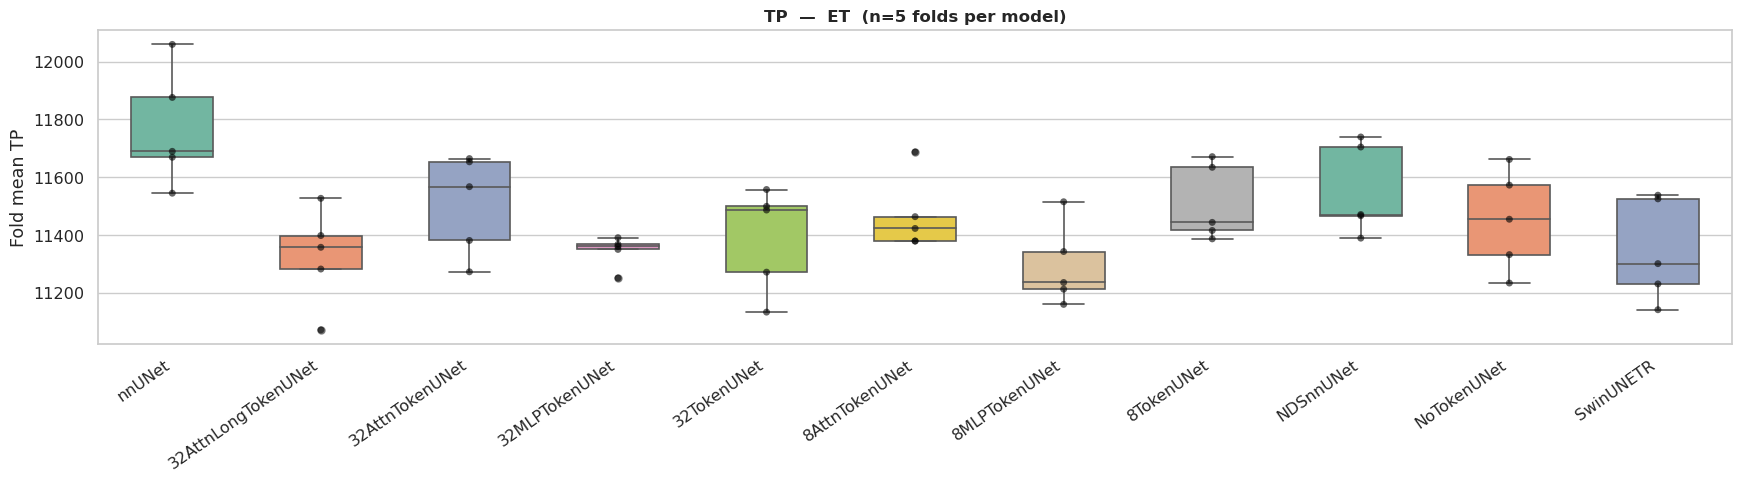

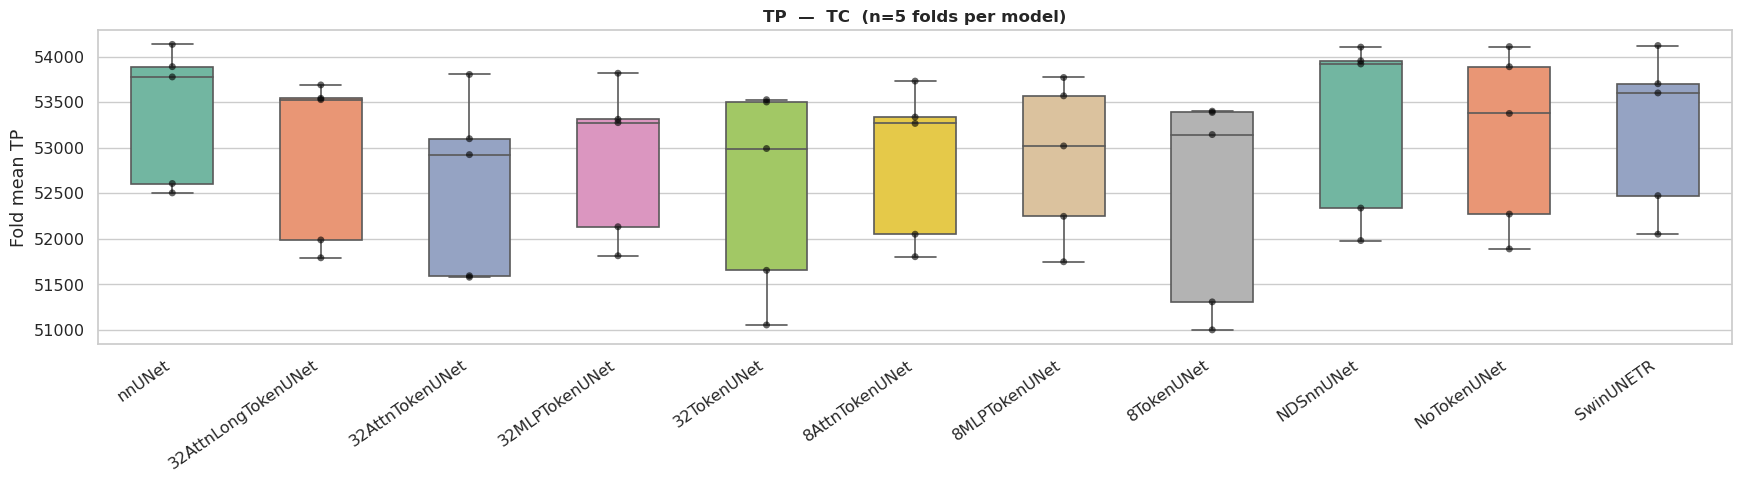

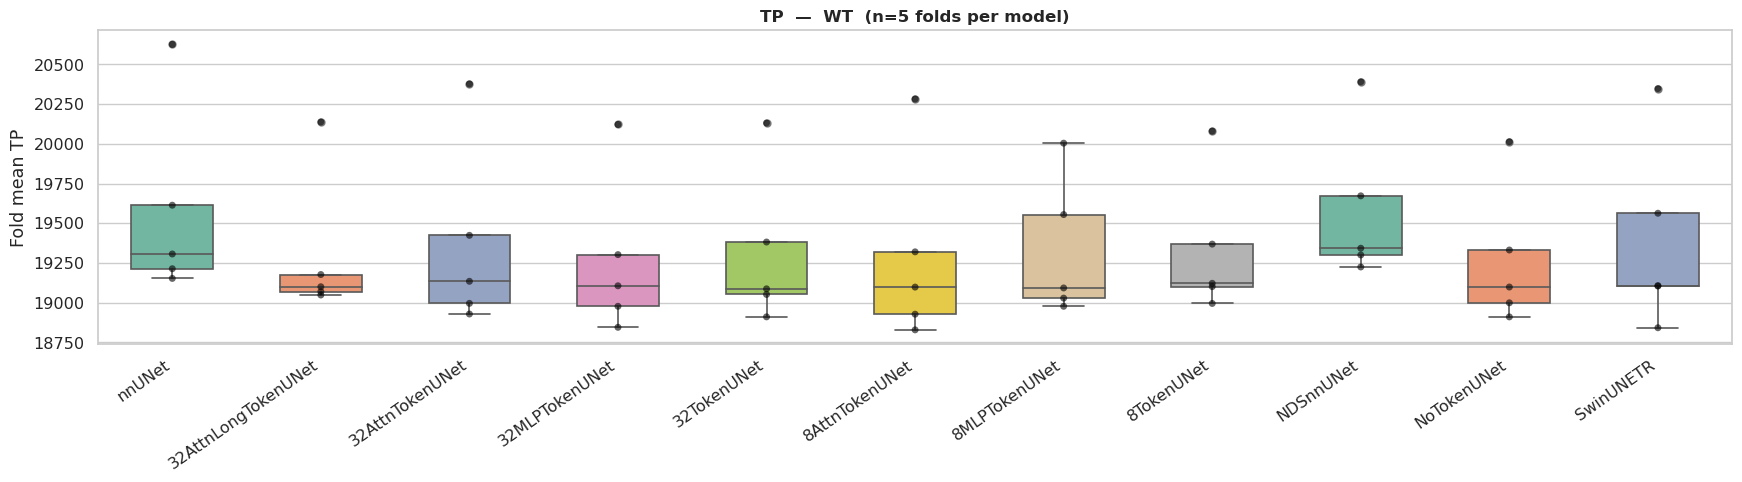

In [2]:
stats, df = analyze_nnunet_results("/data/tshimanga/nnUNet_results/Dataset001_FeTS")